# Analisis matriz de conteos 

Una vez cuantificados los conteos se necesita hacer un analisis de los datos obtenidos, esto con el objetivo de eliminar el ruido o determinar los cutoffs para la limpieza de la matriz

In [8]:
import pandas as pd 

#cargar la matriz de conteos
df_count = pd.read_csv("../../results/pasilla_ejemplo/matrix/All_counts.pasilla.txt", sep="\t", index_col=0) 


#En los archivos SRR de pasilla las muestras untreated son las referentes a las terminasciones *76-*78 y la *82 las 3 remanentes corresponden a muestras treated
#Ordenamos la matriz de acuerdo a los datos Treated- untreated 
orden=list(range(3,6))+list(range(0,3))+[6]
print(orden)
#la ordenamos con iloc de acuerdo al vector antes creado 
df_count=df_count.iloc[:,orden] 

#cambiamos el nombre de las columnas 
df_count.columns=["Treated_"+ str(i) for i in range (1,4)] + ["Untreated_" + str(i) for i in range(1,5)] 

display(df_count)


[3, 4, 5, 0, 1, 2, 6]


,Treated_1,Treated_2,Treated_3,Untreated_1,Untreated_2,Untreated_3,Untreated_4
ID=FBgn0000003,498,734,1030,452,473,730,268
ID=FBgn0000008,165,196,201,179,261,194,196
ID=FBgn0000014,3,1,1,7,0,0,4
ID=FBgn0000015,2,1,1,1,1,2,1
ID=FBgn0000017,7687,6534,8085,9702,10088,7066,6989
...,...,...,...,...,...,...,...
ID=FBgn0290417,144,199,256,192,202,221,208
ID=FBgn0290418,1145,1576,1856,1347,1725,1702,1724
ID=FBgn0290419,1121,1342,1726,2536,3188,2818,2850
ID=FBgn0290420,146,173,222,172,176,203,201


Pequeña normalizacion de los datos para hacer graficas y ver la distribucion de los datos

In [9]:
import numpy as np 

df_log= np.log2(df_count + 1) 

df_log 


,Treated_1,Treated_2,Treated_3,Untreated_1,Untreated_2,Untreated_3,Untreated_4
ID=FBgn0000003,8.962896,9.521600,10.009829,8.823367,8.888743,9.513728,8.071462
ID=FBgn0000008,7.375039,7.622052,7.658211,7.491853,8.033423,7.607330,7.622052
ID=FBgn0000014,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,2.321928
ID=FBgn0000015,1.584963,1.000000,1.000000,1.000000,1.000000,1.584963,1.000000
ID=FBgn0000017,12.908393,12.673972,12.981210,13.244215,13.300496,12.786882,12.771077
...,...,...,...,...,...,...,...
ID=FBgn0290417,7.179909,7.643856,8.005625,7.592457,7.665336,7.794416,7.707359
ID=FBgn0290418,10.162391,10.622967,10.858758,10.396605,10.753217,10.733863,10.752381
ID=FBgn0290419,10.131857,10.391244,10.754052,11.308908,11.638888,11.460968,11.477252
ID=FBgn0290420,7.199672,7.442943,7.800900,7.434628,7.467606,7.672425,7.658211


## Analisis preliminar de datos

In [10]:
## necesitamos el foramto largo del  data frame

#con melt creamos un data frame con solo 2 columnas y por lo tanto num_index= num filas * num col
df_logmelt= df_log.melt(var_name="sample", value_name="Value") 

#agregamos una columna con la cualidad de ser treated o untrated
df_logmelt["Cond"]= df_logmelt["sample"].str.replace("_.$","", regex=True)

display(df_logmelt) 

,sample,Value,Cond
0,Treated_1,8.962896,Treated
1,Treated_1,7.375039,Treated
2,Treated_1,2.000000,Treated
3,Treated_1,1.584963,Treated
4,Treated_1,12.908393,Treated
...,...,...,...
125099,Untreated_4,7.707359,Untreated
125100,Untreated_4,10.752381,Untreated
125101,Untreated_4,11.477252,Untreated
125102,Untreated_4,7.658211,Untreated


### Boxplot 

El boxplot nos ayuda a conocer como se dsitribuyen los conteos de cada muestra, de acuerdo a esto podemos ver que tan variantes son nuestras replicas, lo cual no deberia ser tan variante por el hecho de ser replicas

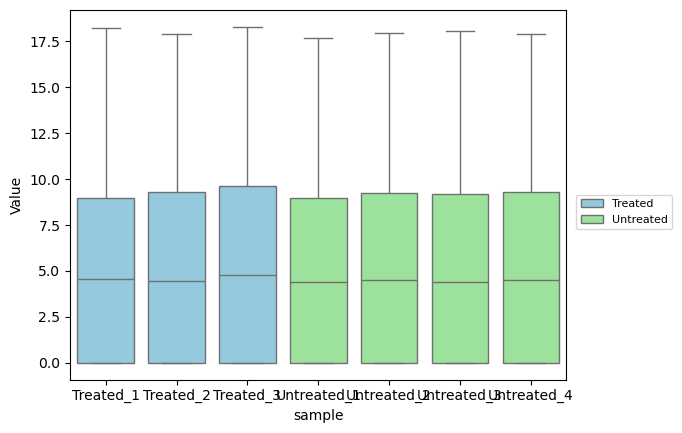

In [11]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.boxplot(data= df_logmelt, x="sample", y="Value", hue="Cond", palette={"Treated": "skyblue", "Untreated":"lightgreen"}) 

plt.legend(
    bbox_to_anchor=(1.02, 0.5),   # posición fuera del eje,  en terminos de las coordenadas de acuerdo al borde de la grafica (esquina inferior izquierda (0,0))
    loc='upper left',           # punto de anclaje de la leyenda
    borderaxespad=0, #tamaño del recuadro 
    fontsize = 8,
    title_fontsize=20
)


### Grafico de Densidad  

Por otro lado el grafico de densidad nos sirve para saber como se dsitribuyen los conteos de lecturas, este grafico puede ser muy util para saber donde poner el punto de corte a la hora de limpiar aquellos conteos que no tienen fuerza estadisdica, como el metodo de cut off por conteos por millon 

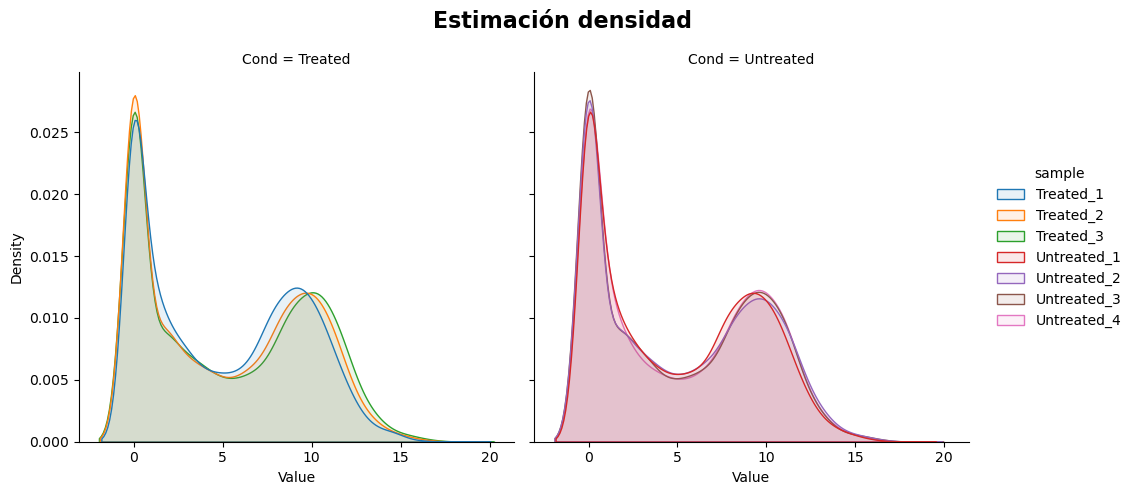

In [12]:
graf=sns.displot( data=df_logmelt, x="Value", hue="sample", col= "Cond", kind="kde", fill=True, alpha= 0.1) 

graf.figure.suptitle("Estimación densidad", fontsize=16, fontweight="bold") 
graf.tight_layout()
plt.show()

### PCA 
Analisis de reduccion de la dimensionalidad de los datos comparando las varianzas de los mismos, este analizis nos ayuda a ver como la varianza en los conteos de los datos agrupan a nuestras ditintas condiciones, se hace a partir del data frame normalizado y ayuda para conocer si alguna muestra no se agrupa como deberia lo que nos puede hablar de un fuerte efecto de lote o batch effect

In [13]:
from sklearn.decomposition import PCA 


#transpner datos 
expresion_df= df_log.T 

# obejto tipo PCA 
pca= PCA(n_components=2) 

principal_components=pca.fit_transform(expresion_df)

#data frame con los componentes principales 
Condiciones=df_log.columns.str.replace("_.$","", regex=True) 

pca_df=pd.DataFrame(data=principal_components, columns=["PC1", "PC2"], index=expresion_df.index)
pca_df["Condiciones"]=Condiciones 
display(pca_df)

,PC1,PC2,Condiciones
Treated_1,64.802992,-34.788795,Treated
Treated_2,-23.733311,-31.004084,Treated
Treated_3,-51.669318,-38.588048,Treated
Untreated_1,52.508868,15.258890,Untreated
Untreated_2,-15.348145,31.637755,Untreated
Untreated_3,-19.055079,31.119252,Untreated
Untreated_4,-7.506007,26.365028,Untreated


Representando los componentes principales con un scatterplot

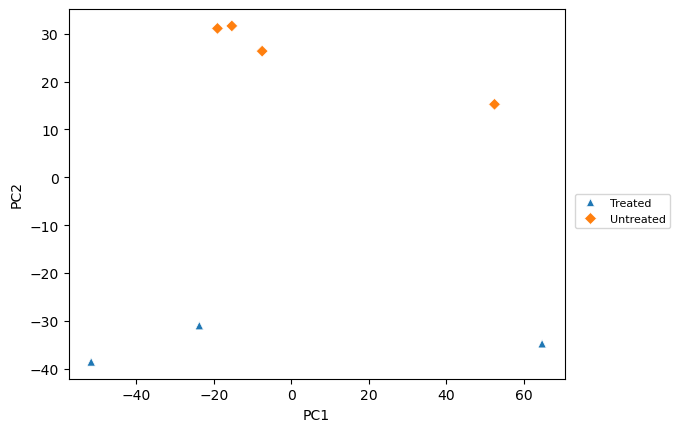

In [14]:
sns.scatterplot(data=pca_df, 
                x="PC1", 
                y="PC2", 
                hue="Condiciones", 
                style="Condiciones",
                markers={"Treated": "^", "Untreated": "D"}) 

plt.legend(
    bbox_to_anchor=(1.02, 0.5),   # posición fuera del eje,  en terminos de las coordenadas de acuerdo al borde de la grafica (esquina inferior izquierda (0,0))
    loc='upper left',           # punto de anclaje de la leyenda
    borderaxespad=0, #tamaño del recuadro 
    fontsize = 8,
    title_fontsize=20
)

plt.show() 



## Filtrado de datos

In [15]:
# Función para calcular los conteos por millón

def cpm(df):
    """
    Calcula los conteos por millón (CPM) de un DataFrame de conteos brutos.

    Args:
        df (pd.DataFrame): DataFrame con valores numéricos (conteos de genes)
    
    Returns:
        pd.DataFrame: DataFrame con los valores de CPM
    """
    return (df / df.sum()) * 1000000

In [16]:
# Filtrando la tabla de conteos, con U = 5 
# en un número mínimo de muestras n= 3
df_countFilter=df_count[(cpm(df_count)>=5).sum(axis=1)>=3]
display(df_countFilter.head())

print(df_countFilter.shape)

df_countFilter.to_csv("../../results/pasilla_ejemplo/tables_txt/Filtered_count.csv")


,Treated_1,Treated_2,Treated_3,Untreated_1,Untreated_2,Untreated_3,Untreated_4
ID=FBgn0000003,498,734,1030,452,473,730,268
ID=FBgn0000008,165,196,201,179,261,194,196
ID=FBgn0000017,7687,6534,8085,9702,10088,7066,6989
ID=FBgn0000018,422,530,609,421,480,516,601
ID=FBgn0000032,989,1200,1481,914,1219,1142,1550


(7700, 7)


## Analisis de expresion `pyDeseq2` 


In [17]:
# Cargando los modulos de pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.preprocessing import deseq2_norm

import os

# Haciendo la transpuesta de la tabla de conteos
df_CountFilter_T = df_countFilter.T
display(df_CountFilter_T.head())

,ID=FBgn0000003,ID=FBgn0000008,ID=FBgn0000017,ID=FBgn0000018,ID=FBgn0000032,ID=FBgn0000042,ID=FBgn0000043,ID=FBgn0000044,ID=FBgn0000046,ID=FBgn0000052,...,ID=FBgn0290324,ID=FBgn0290396,ID=FBgn0290397,ID=FBgn0290399,ID=FBgn0290416,ID=FBgn0290417,ID=FBgn0290418,ID=FBgn0290419,ID=FBgn0290420,ID=FBgn0290421
Treated_1,498,165,7687,422,989,78204,35468,1128,3204,1903,...,573,346,632,176,9487,144,1145,1121,146,1185
Treated_2,734,196,6534,530,1200,132590,53730,222,878,3099,...,791,422,1224,197,15293,199,1576,1342,173,1655
Treated_3,1030,201,8085,609,1481,166888,68309,132,858,3778,...,1027,527,1401,240,17225,256,1856,1726,222,2044
Untreated_1,452,179,9702,421,914,71966,24867,873,3435,2069,...,631,379,708,154,11693,192,1347,2536,172,1158
Untreated_2,473,261,10088,480,1219,91957,31912,108,493,3227,...,713,374,1059,156,18051,202,1725,3188,176,1408


In [18]:
# Creación de la matriz de diseño
metadata = pd.DataFrame(Condiciones, columns=["condition"], index=df_CountFilter_T.index)
print(metadata)

             condition
Treated_1      Treated
Treated_2      Treated
Treated_3      Treated
Untreated_1  Untreated
Untreated_2  Untreated
Untreated_3  Untreated
Untreated_4  Untreated


In [19]:
# Creando el objeto dds
dds = DeseqDataSet(
    counts = df_CountFilter_T,
    metadata = metadata
)
print(dds)

AnnData object with n_obs × n_vars = 7 × 7700
    obs: 'condition'
    obsm: 'design_matrix'


### Normalización y cálculo de dispersión


Una vez creado el objeto `DeseqDataSet`, se ejecuta el método `deseq2()`, el cual lleva a cabo varios pasos fundamentales del análisis de expresión diferencial.  

Primero, realiza la **normalización** de los conteos mediante la estimación de **factores de tamaño**, que compensan las diferencias en la **profundidad de secuenciación** entre muestras. Después, estima la **dispersión** de cada gen, que representa la **variabilidad biológica** entre réplicas, y finalmente ajusta el modelo estadístico para calcular los **cambios en la expresión génica (log₂ fold change)** entre las condiciones experimentales.  

En este punto, los **parámetros del análisis** se almacenan organizando los campos por claves. En particular:

- **`X`** almacena los **datos de conteo**.  
- **`obs`** contiene información **a nivel de muestra (1D)**, como los **factores de diseño** y los **`size_factors`** utilizados en la normalización.  
- **`obsm`** guarda información **multidimensional a nivel de muestra**, como la **matriz de diseño (`design_matrix`)**.  
- **`var`** almacena información **a nivel de gen (1D)**, como los **nombres de los genes** y las **dispersiónes (`dispersions`)** estimadas.  
- **`varm`** contiene información **multidimensional a nivel de gen**, como los **valores de cambio en la expresión (`LFC`)**.

Como ejemplo, a continuación se muestra cómo podemos acceder a las  muestras y valores de **normalización**, a las **dispersiónes** y a los **valores de cambio en la expresión (LFCs)** en **escala logarítmica natural**:

In [20]:
# Aplicar el método deseq2 a los datos
dds.deseq2() 

# Solicitando la información de las muestras
print("***** Información de las muestras *****")
print(dds.obs)

# Solicitando la información de la dispersión
print("***** Información de la dispersión *****")
print(dds.var["dispersions"])

# Solicitando los valores de cambio LFC
print("***** Información de LFC *****")
print(dds.varm["LFC"])

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.05 seconds.

Fitting dispersion trend curve...
... done in 0.15 seconds.

Fitting MAP dispersions...
... done in 0.94 seconds.

Fitting LFCs...


***** Información de las muestras *****
             condition  size_factors  replaceable
Treated_1      Treated      0.801590        False
Treated_2      Treated      1.045472        False
Treated_3      Treated      1.328294        False
Untreated_1  Untreated      0.847915        False
Untreated_2  Untreated      1.036738        False
Untreated_3  Untreated      1.011321        False
Untreated_4  Untreated      1.025047        False
***** Información de la dispersión *****
ID=FBgn0000003    0.069279
ID=FBgn0000008    0.025475
ID=FBgn0000017    0.047534
ID=FBgn0000018    0.013952
ID=FBgn0000032    0.018471
                    ...   
ID=FBgn0290417    0.013904
ID=FBgn0290418    0.006243
ID=FBgn0290419    0.007474
ID=FBgn0290420    0.015686
ID=FBgn0290421    0.011818
Name: dispersions, Length: 7700, dtype: float64
***** Información de LFC *****
                Intercept  condition[T.Untreated]
ID=FBgn0000003   6.550863               -0.350221
ID=FBgn0000008   5.197155                0.

... done in 0.88 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



### 6.4 Análisis estadístico con la clase `DeseqStats`

Una vez realizada la **normalización**, el cálculo de la **dispersión** y obtenidos los **valores de cambio en la expresión (LFC)**, se pueden realizar las **pruebas estadísticas** para calcular los **p-values** y los **p-values ajustados**, fundamentales para identificar genes diferencialmente expresados.

Para ello, utilizaremos la función `DeseqStats`, que requiere dos argumentos obligatorios:

- **`dds`**: el objeto `DESeqDataSet` que contiene la información de **normalización** y **dispersión**.  
- **`contrast`**: una lista de 3 cadenas de la forma `["variable", "condición_prueba", "condición_basal"]`, que define la comparación de interés.

La función crea un objeto de la clase `DeseqStats`, que se utilizará posteriormente para calcular los **p-values** y realizar el análisis estadístico de la expresión diferencial. 

> utilizando la función `summary()` se ejecutan todas las **pruebas estadísticas**, calculando los **p-values** y los **p-values ajustados**, haciendo uso de la > información de normalización y dispersión previamente almacenada en el objeto `DeseqStats`. 

In [22]:
# Creando el objeto de tipo DeseqStats
ds = DeseqStats(dds, contrast=["condition", "Treated","Untreated"])
print(ds) 

# EvaluandoCalculando las pruebas estadísticas
ds.summary()

# Guardando los resultados en res_df_pyDESeq2
res_df_pyDESeq2 = ds.results_df
res_df_pyDESeq2.head()


Running Wald tests...


Log2 fold change & Wald test p-value: condition Treated vs Untreated
                   baseMean  log2FoldChange     lfcSE       stat  \
ID=FBgn0000003   581.623076        0.505262  0.293553   1.721196   
ID=FBgn0000008   198.647746       -0.226637  0.192897  -1.174910   
ID=FBgn0000017  8129.154731       -0.258866  0.240556  -1.076115   
ID=FBgn0000018   506.846510       -0.049959  0.139098  -0.359166   
ID=FBgn0000032  1198.807476       -0.071286  0.153130  -0.465525   
...                     ...             ...       ...        ...   
ID=FBgn0290417   200.777041       -0.163792  0.151701  -1.079699   
ID=FBgn0290418  1564.348830       -0.196216  0.091509  -2.144226   
ID=FBgn0290419  2230.603256       -1.132557  0.098852 -11.457051   
ID=FBgn0290420   183.453578       -0.166700  0.160527  -1.038455   
ID=FBgn0290421  1469.478881        0.109420  0.123161   0.888426   

                      pvalue          padj  
ID=FBgn0000003  8.521531e-02  3.991446e-01  
ID=FBgn0000008  2.400306

... done in 1.09 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ID=FBgn0000003,581.623076,0.505262,0.293553,1.721196,0.085215,0.399145
ID=FBgn0000008,198.647746,-0.226637,0.192897,-1.174910,0.240031,0.682245
ID=FBgn0000017,8129.154731,-0.258866,0.240556,-1.076115,0.281876,0.727152
ID=FBgn0000018,506.846510,-0.049959,0.139098,-0.359166,0.719471,0.946485
ID=FBgn0000032,1198.807476,-0.071286,0.153130,-0.465525,0.641555,0.920818


Entre los atributos disponibles se encuentran:

- **`padj`**: p-value ajustado, útil para controlar la tasa de falsos positivos.  
- **`log2FoldChange`**: cambio en la expresión en escala log₂ entre condiciones.

Estos valores permiten **identificar y filtrar genes con expresión diferencial significativa**.

## Interpretación de resultados

### Genes sub y sobre expresados

Para obtener los nombres de los genes que se encuentran **sobreexpresados** o **subexpresados**, realizaremos un **filtrado de los resultados**, considerando los siguientes criterios:

- **Magnitud del cambio (`log2FoldChange`)**: al menos ±2  
- **p-value ajustado (`padj`)**: ≤ 0.01

Este filtrado nos permitirá identificar genes con cambios de expresión **estadísticamente significativos** y de **magnitud relevante**.

Esta tarea la realizaremos con la función `select` de la biblioteca **NumPy**:

In [24]:

# Definir las condiciones con los valores de corte
cond = [ (res_df_pyDESeq2["padj"] <= 0.01) & (res_df_pyDESeq2["log2FoldChange"] >= 2),(res_df_pyDESeq2["padj"] <= 0.01) & (res_df_pyDESeq2["log2FoldChange"] <= -2)]

# Definir los valores correspondientes
opc = ["UP", "DOWN"]

# Crear la nueva columna
res_df_pyDESeq2["Expression"] = np.select(cond, opc, default = "Non-DE")


# Desplegando el dataframe
display(res_df_pyDESeq2.head())

# Contando los valores asociados a cada categoría de la columna Expresion

conteo = res_df_pyDESeq2["Expression"].value_counts()
print(conteo)


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Expression
ID=FBgn0000003,581.623076,0.505262,0.293553,1.721196,0.085215,0.399145,Non-DE
ID=FBgn0000008,198.647746,-0.226637,0.192897,-1.174910,0.240031,0.682245,Non-DE
ID=FBgn0000017,8129.154731,-0.258866,0.240556,-1.076115,0.281876,0.727152,Non-DE
ID=FBgn0000018,506.846510,-0.049959,0.139098,-0.359166,0.719471,0.946485,Non-DE
ID=FBgn0000032,1198.807476,-0.071286,0.153130,-0.465525,0.641555,0.920818,Non-DE


Expression
Non-DE    7664
DOWN        22
UP          14
Name: count, dtype: int64


### Interpretación grafica de los resultados

Una forma eficaz de **resumir e interpretar** los resultados del análisis de expresión diferencial es mediante su **visualización gráfica**. Para ello, utilizaremos dos tipos de representaciones: el **volcano plot** y los **mapas de calor (heatmaps)**, que permiten identificar patrones y genes diferencialmente expresados de manera más intuitiva.

### Gráfica de Volcano

El **volcano plot** es una gráfica de dispersión que combina la **magnitud del cambio de expresión** (`log2FoldChange`) con la **significancia estadística** (`-log10(padj)`), permitiendo identificar de forma rápida los genes **sobreexpresados** y **subexpresados** de manera significativa.

Antes de generar la gráfica, calcularemos el valor de `-log10(padj)` utilizando la biblioteca **NumPy**, ya que este valor se empleará para representar el eje **Y** de la gráfica.


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Expression,log10Neg
ID=FBgn0000003,581.623076,0.505262,0.293553,1.721196,0.085215,0.399145,Non-DE,0.398870
ID=FBgn0000008,198.647746,-0.226637,0.192897,-1.174910,0.240031,0.682245,Non-DE,0.166059
ID=FBgn0000017,8129.154731,-0.258866,0.240556,-1.076115,0.281876,0.727152,Non-DE,0.138375
ID=FBgn0000018,506.846510,-0.049959,0.139098,-0.359166,0.719471,0.946485,Non-DE,0.023886
ID=FBgn0000032,1198.807476,-0.071286,0.153130,-0.465525,0.641555,0.920818,Non-DE,0.035826


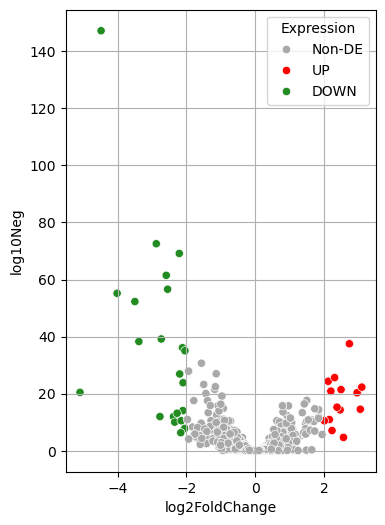

In [25]:
# Crear la columna log10Neg
res_df_pyDESeq2["log10Neg"] = -np.log10(res_df_pyDESeq2["padj"])
display(res_df_pyDESeq2.head()) 


# Creando la gráfica de puntos
plt.figure(figsize=(4,6))
colores = {
    "UP": "red",
    "DOWN": "forestgreen",
    "Non-DE": "darkgray",
}

sns.scatterplot(data=res_df_pyDESeq2, x="log2FoldChange", y="log10Neg", hue = "Expression", palette = colores)
plt.grid(True)
plt.show()



### Heatmap

Además de la **gráfica de Volcano**, también podemos generar un **mapa de calor (heatmap)** para visualizar y contrastar la expresión de los **genes diferencialmente expresados** de manera significativa entre condiciones.  

Para ello, primero **obtenemos los conteos normalizados** utilizando la función `deseq2_norm()` y seleccionamos únicamente los **genes significativos** (aquellos clasificados como *UP* o *DOWN*).  

Posteriormente, aplicamos una **normalización tipo Z-score por gen**, lo que permite centrar y escalar los valores de expresión, facilitando la comparación entre muestras y genes.  

Finalmente, utilizamos la función `clustermap()` de **seaborn**, que genera el mapa de calor agrupando tanto los genes como las muestras según su similitud en los patrones de expresión.


Index(['ID=FBgn0000071', 'ID=FBgn0000406', 'ID=FBgn0002868', 'ID=FBgn0003360',
       'ID=FBgn0011260', 'ID=FBgn0016715', 'ID=FBgn0024315', 'ID=FBgn0026562',
       'ID=FBgn0029167', 'ID=FBgn0029896', 'ID=FBgn0030041', 'ID=FBgn0032405',
       'ID=FBgn0033775', 'ID=FBgn0034389', 'ID=FBgn0034736', 'ID=FBgn0035085',
       'ID=FBgn0035189', 'ID=FBgn0037290', 'ID=FBgn0037754', 'ID=FBgn0038198',
       'ID=FBgn0038832', 'ID=FBgn0039155', 'ID=FBgn0039827', 'ID=FBgn0040827',
       'ID=FBgn0051642', 'ID=FBgn0052407', 'ID=FBgn0085359', 'ID=FBgn0260011',
       'ID=FBgn0261284', 'ID=FBgn0261584', 'ID=FBgn0261673', 'ID=FBgn0262733',
       'ID=FBgn0264272', 'ID=FBgn0264437', 'ID=FBgn0264475', 'ID=FBgn0264753'],
      dtype='object')


,Treated_1,Treated_2,Treated_3,Untreated_1,Untreated_2,Untreated_3,Untreated_4
ID=FBgn0000071,6.627710,6.660002,6.769110,4.854927,4.933989,4.923297,4.394404
ID=FBgn0000406,4.637605,4.656425,4.938233,6.223743,6.215896,6.509380,5.460163
ID=FBgn0002868,4.088217,3.422688,3.654347,5.467523,4.743353,4.879176,5.584826
ID=FBgn0003360,7.219486,7.070338,7.028210,9.175870,8.924907,9.016962,9.249987
ID=FBgn0011260,6.260940,5.911487,5.837123,4.617552,4.518184,4.332695,4.529403
ID=FBgn0016715,3.977733,4.260211,4.219555,5.665612,5.602406,5.685874,5.468427
ID=FBgn0024315,2.915892,3.358244,3.764899,4.798226,5.168129,5.051409,5.134461
ID=FBgn0026562,9.277041,9.763447,9.846701,10.936966,11.458163,11.550401,11.036527
ID=FBgn0029167,7.212152,7.400392,7.216263,8.733592,8.894023,8.812392,8.786918
ID=FBgn0029896,5.461854,5.202795,5.330430,6.808567,6.939369,6.741026,6.674793


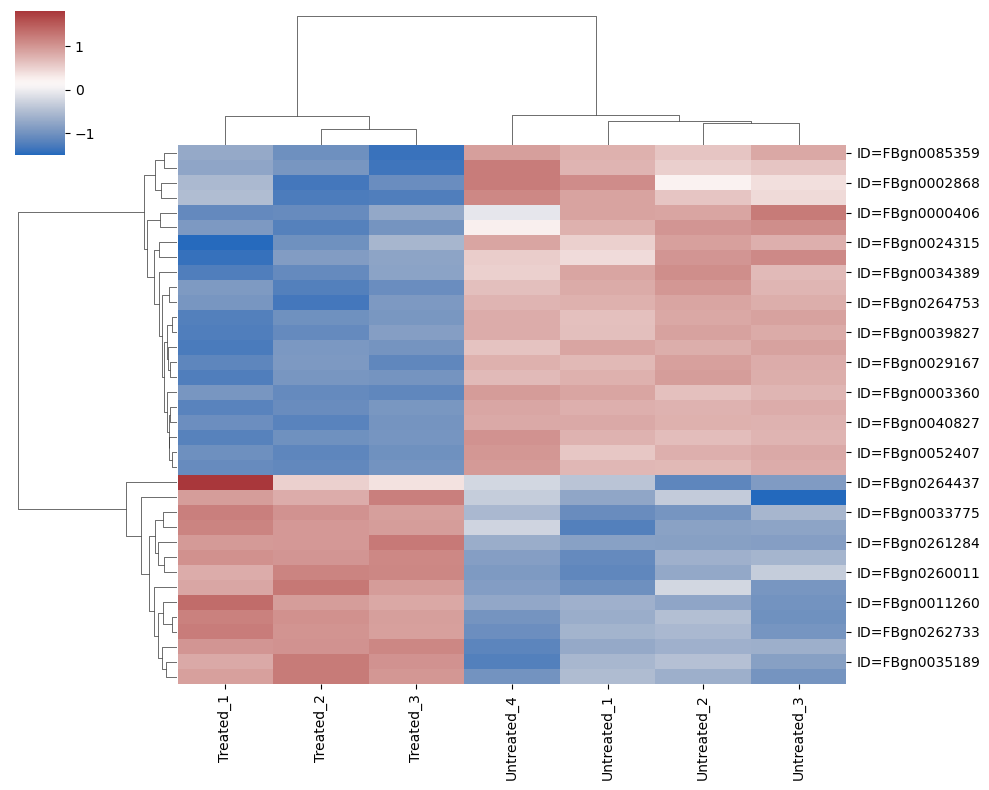

In [27]:
# Obtener los conteos normalizados, estos dependen de la biblioteca de pydeseq2
# Existen dos maneras de obtenerlos
# 1. Con la función deseq2_norm(
normalizacion = deseq2_norm(df_CountFilter_T)

# 2. Directamente del objeto dds
normCounts = pd.DataFrame(dds.layers['normed_counts'].T,index=dds.var_names,columns=dds.obs_names)#normalizacion[0]

# Seleccionando los genes significativos
genes = res_df_pyDESeq2[res_df_pyDESeq2["Expression"] != "Non-DE"].index
print(genes)

# Aplicando un logaritmo a los conteos para achatar picos
heatmap_data = np.log1p(normCounts.loc[genes])
display(heatmap_data)

# Graficando el heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(data= heatmap_data,
              z_score=0,
              cmap="vlag",
              col_cluster=True,
              row_cluster=True,
              figsize =(10,8))

plt.show()
